In [433]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [434]:
data = pd.read_csv('../bitcoin_data/raw/btc_binance_daily.csv')
data.head()


,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [435]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1000 non-null   str    
 1   open    1000 non-null   float64
 2   high    1000 non-null   float64
 3   low     1000 non-null   float64
 4   close   1000 non-null   float64
 5   volume  1000 non-null   float64
dtypes: float64(5), str(1)
memory usage: 47.0 KB


In [436]:
## take values for 3 decimal
cols = ["open", "high", "low", "close", "volume"]

data[cols] = data[cols].astype(float).round(3)

In [437]:
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.934
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.103
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.433
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.522
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.219


In [438]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

In [439]:
df = data.copy()

In [440]:
### Check duplicate values
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


In [441]:
### Check missing values
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values)


Number of missing values: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [442]:
### Statistical overview

summary = df.drop(columns=["date"]).describe().round(3)
print(summary)

             open        high         low       close      volume
count    1000.000    1000.000    1000.000    1000.000    1000.000
mean    77163.065   78527.891   75731.818   77199.740   27660.586
std     24583.530   24836.965   24240.291   24535.328   18602.239
min     26221.680   26397.460   25990.460   26221.670    3104.117
25%     62079.002   63426.162   60653.502   62123.102   15467.079
50%     74020.460   75479.880   73080.750   74020.455   23092.700
75%     96847.298   98288.750   95208.090   96847.300   34445.785
max    124658.540  126199.630  123084.000  124658.540  162065.592


* Check zero or negative values

In [443]:
cols = ["open", "high", "low", "close", "volume"]

invalid_values = df[(df[cols] <= 0).any(axis=1)]

print(invalid_values)

Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


* Check outliers

In [444]:
df["daily_return_temp"] = df["close"].pct_change()

outliers = df[abs(df["daily_return_temp"]) > 0.20]

print(outliers[["date", "close", "daily_return_temp"]])

Empty DataFrame
Columns: [date, close, daily_return_temp]
Index: []


In [445]:
df = df.sort_values("date").reset_index(drop=True)

### Feature Engineering

* Log Return Features

In [446]:
periods = [1, 2, 5, 10]

for p in periods:
    col_name = "log_return" if p == 1 else f"log_return_{p}d"
    df[col_name] = np.log(df["close"] / df["close"].shift(p))

In [447]:
df[["log_return", "log_return_2d", "log_return_5d", "log_return_10d"]].isna().sum()

log_return         1
log_return_2d      2
log_return_5d      5
log_return_10d    10
dtype: int64

* Price Ratios

In [448]:
# Price ratios
df["high_low_ratio"] = df["high"] / df["low"]
df["close_open_ratio"] = df["close"] / df["open"]
df["high_close_ratio"] = df["high"] / df["close"]
df["low_close_ratio"] = df["low"] / df["close"]

# Daily range relative to close
df["range_ratio"] = (df["high"] - df["low"]) / df["close"]

# Candle body size relative to close
df["body_ratio"] = abs(df["close"] - df["open"]) / df["close"]

# Upper and lower shadow ratios
df["upper_shadow_ratio"] = (
    df["high"] - df[["open", "close"]].max(axis=1)
) / df["close"]

df["lower_shadow_ratio"] = (
    df[["open", "close"]].min(axis=1) - df["low"]
) / df["close"]

* Rolling Windows

In [449]:
# Rolling stats on log-return
return_windows = [7, 14, 30]

for w in return_windows:
    rolling_return = df["log_return"].rolling(window=w)

    df[f"return_mean_{w}d"] = rolling_return.mean()
    df[f"return_std_{w}d"] = rolling_return.std()
    df[f"return_skew_{w}d"] = rolling_return.skew()
    df[f"return_kurt_{w}d"] = rolling_return.kurt()

# Price distance from rolling highs / lows
price_windows = [7, 30, 90]

for w in price_windows:
    rolling_high = df["high"].rolling(window=w).max()
    rolling_low = df["low"].rolling(window=w).min()

    df[f"dist_from_high_{w}d"] = (df["close"] - rolling_high) / df["close"]
    df[f"dist_from_low_{w}d"] = (df["close"] - rolling_low) / df["close"]

In [450]:
import pandas as pd
from ta import momentum, trend


def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    RSI, MACD, Stochastic, ROC, Williams %R, CCI.
    Source: Jung et al. (2023) — Computer Systems Science & Engineering.
    """

    features = {}

    # RSI — multiple windows
    for w in [9, 14, 21]:
        features[f"rsi_{w}"] = momentum.RSIIndicator(
            close=df["close"],
            window=w
        ).rsi()

    # MACD
    macd_obj = trend.MACD(
        close=df["close"],
        window_slow=26,
        window_fast=12,
        window_sign=9
    )

    features["macd"] = macd_obj.macd()
    features["macd_signal"] = macd_obj.macd_signal()
    features["macd_hist"] = macd_obj.macd_diff()

    # Stochastic Oscillator
    for w in [9, 14, 21]:
        stoch_obj = momentum.StochasticOscillator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            smooth_window=3
        )

        features[f"stoch_k_{w}"] = stoch_obj.stoch()
        features[f"stoch_d_{w}"] = stoch_obj.stoch_signal()

    # Rate of Change — ROC
    for w in [9, 14, 21]:
        features[f"roc_{w}"] = momentum.ROCIndicator(
            close=df["close"],
            window=w
        ).roc()

    # Williams %R
    for w in [9, 14, 21]:
        features[f"williams_r_{w}"] = momentum.WilliamsRIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            lbp=w
        ).williams_r()

    # Commodity Channel Index — CCI
    for w in [14, 20, 30]:
        features[f"cci_{w}"] = trend.CCIIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            constant=0.015
        ).cci()

    feature_df = pd.DataFrame(features, index=df.index)

    return pd.concat([df, feature_df], axis=1)

In [451]:
df = add_momentum_features(df)

print(df.head())

        date      open      high       low     close     volume  \
0 2023-09-16  26599.99  26777.00  26445.00  26559.67  13960.934   
1 2023-09-17  26559.67  26623.25  26399.00  26527.51  12998.103   
2 2023-09-18  26527.50  27409.00  26377.35  26762.51  43000.433   
3 2023-09-19  26762.50  27483.57  26667.79  27210.26  36190.522   
4 2023-09-20  27210.25  27388.63  26800.00  27125.00  34207.219   

   daily_return_temp  log_return  log_return_2d  log_return_5d  ...  \
0                NaN         NaN            NaN            NaN  ...   
1          -0.001211   -0.001212            NaN            NaN  ...   
2           0.008859    0.008820       0.007608            NaN  ...   
3           0.016730    0.016592       0.025412            NaN  ...   
4          -0.003133   -0.003138       0.013454            NaN  ...   

   stoch_d_21  roc_9  roc_14  roc_21  williams_r_9  williams_r_14  \
0         NaN    NaN     NaN     NaN           NaN            NaN   
1         NaN    NaN     NaN    

In [452]:
from ta import trend


def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    SMA, EMA, TEMA, ADX, PSAR, Ichimoku.
    """


    # Simple Moving Averages
    for w in [7, 21, 50, 200]:
        df[f"sma_{w}"] = trend.SMAIndicator(
            close=df["close"],
            window=w
        ).sma_indicator()

        df[f"price_vs_sma_{w}"] = (
            df["close"] - df[f"sma_{w}"]
        ) / df[f"sma_{w}"]

    # Exponential Moving Averages
    for w in [9, 12, 26]:
        df[f"ema_{w}"] = trend.EMAIndicator(
            close=df["close"],
            window=w
        ).ema_indicator()

    # TEMA: Triple Exponential Moving Average
    for w in [9, 12, 26]:
        ema1 = df["close"].ewm(span=w, adjust=False).mean()
        ema2 = ema1.ewm(span=w, adjust=False).mean()
        ema3 = ema2.ewm(span=w, adjust=False).mean()

        df[f"tema_{w}"] = 3 * ema1 - 3 * ema2 + ema3

    # EMA / SMA crossover features
    df["ema_9_26_cross"] = df["ema_9"] - df["ema_26"]
    df["sma_50_200_cross"] = df["sma_50"] - df["sma_200"]

    # ADX: trend strength
    adx_obj = trend.ADXIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14
    )

    df["adx"] = adx_obj.adx()
    df["adx_pos"] = adx_obj.adx_pos()
    df["adx_neg"] = adx_obj.adx_neg()

    # Parabolic SAR
    psar = trend.PSARIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"]
    )

    df["psar"] = psar.psar()
    df["psar_up"] = psar.psar_up()
    df["psar_down"] = psar.psar_down()

    # Ichimoku
    ichimoku = trend.IchimokuIndicator(
        high=df["high"],
        low=df["low"],
        window1=9,
        window2=26,
        window3=52
    )

    df["ichimoku_a"] = ichimoku.ichimoku_a()
    df["ichimoku_b"] = ichimoku.ichimoku_b()
    df["ichimoku_base"] = ichimoku.ichimoku_base_line()
    df["ichimoku_conv"] = ichimoku.ichimoku_conversion_line()

    return df

In [453]:
df = add_trend_features(df)

* Volatility Features

In [454]:
from ta import volatility


def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bollinger Bands, ATR, Keltner Channel, Donchian Channel.
    """


    # Make sure log_return exists
    if "log_return" not in df.columns:
        df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # Bollinger Bands
    for w in [14, 20]:
        bb = volatility.BollingerBands(
            close=df["close"],
            window=w,
            window_dev=2
        )

        df[f"bb_upper_{w}"] = bb.bollinger_hband()
        df[f"bb_lower_{w}"] = bb.bollinger_lband()
        df[f"bb_width_{w}"] = bb.bollinger_wband()
        df[f"bb_pct_{w}"] = bb.bollinger_pband()

    # Average True Range
    for w in [7, 14]:
        atr = volatility.AverageTrueRange(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w
        )

        df[f"atr_{w}"] = atr.average_true_range()
        df[f"atr_pct_{w}"] = df[f"atr_{w}"] / df["close"]

    # Keltner Channel
    kc = volatility.KeltnerChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["kc_upper"] = kc.keltner_channel_hband()
    df["kc_lower"] = kc.keltner_channel_lband()
    df["kc_width"] = kc.keltner_channel_wband()

    # Donchian Channel
    dc = volatility.DonchianChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["dc_upper"] = dc.donchian_channel_hband()
    df["dc_lower"] = dc.donchian_channel_lband()
    df["dc_width"] = dc.donchian_channel_wband()

    # Historical volatility annualized
    for w in [7, 14, 30]:
        df[f"hist_vol_{w}d"] = (
            df["log_return"].rolling(w).std() * np.sqrt(365)
        )

    return df

In [455]:
df = add_volatility_features(df)

##### Add Lagged Features

In [456]:
for lag in [1, 2, 3, 5, 7, 10, 14]:
    df[f"log_return_lag_{lag}"] = df["log_return"].shift(lag)

##### Volume Normalized Features

In [457]:
df["volume_log"] = np.log1p(df["volume"])

for w in [7, 14, 30]:
    df[f"volume_zscore_{w}"] = (
        df["volume"] - df["volume"].rolling(w).mean()
    ) / df["volume"].rolling(w).std()

    df[f"volume_vs_sma_{w}"] = (
        df["volume"] / df["volume"].rolling(w).mean()
    ) - 1

In [458]:
# 1. Check which columns have missing values
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

psar_down            549
psar_up              453
sma_50_200_cross     199
price_vs_sma_200     199
sma_200              199
                    ... 
log_return_lag_2       3
log_return_lag_1       2
log_return_2d          2
log_return             1
daily_return_temp      1
Length: 90, dtype: int64


In [459]:
# 2. Drop columns that are completely empty
all_nan_cols = df.columns[df.isna().all()].tolist()

print("Fully empty columns:", all_nan_cols)

df = df.drop(columns=all_nan_cols)

Fully empty columns: []


In [460]:
# 3. Fill PSAR direction columns instead of dropping rows
for col in ["psar_up", "psar_down", "sma_50_200_cross", "price_vs_sma_200", "sma_200"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

* Target Feature

In [461]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

In [462]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 910
Rows dropped: 90


In [463]:
# Drop rows where target is missing
df = df.dropna(subset=["target_pct_change"]).reset_index(drop=True)

In [464]:
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (910, 120)


In [465]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change     1.000000
high_close_ratio      0.093035
upper_shadow_ratio    0.090499
low_close_ratio       0.064739
return_skew_14d       0.060837
                        ...   
ema_26               -0.069547
dc_lower             -0.070013
close                -0.071134
sma_50               -0.071374
bb_lower_20          -0.071558
Name: target_pct_change, Length: 119, dtype: float64


In [466]:
corr_with_target = corr_with_target.drop(
    labels=["target_pct_change"],
    errors="ignore"
)

print(corr_with_target.head(30))
print(corr_with_target.tail(30))

high_close_ratio      0.093035
upper_shadow_ratio    0.090499
low_close_ratio       0.064739
return_skew_14d       0.060837
bb_width_20           0.047617
volume                0.046268
volume_log            0.036420
dc_width              0.034604
bb_width_14           0.033443
atr_pct_7             0.031705
atr_pct_14            0.031199
return_kurt_14d       0.030614
return_skew_30d       0.029997
adx_pos               0.029852
log_return_lag_10     0.029337
cci_14                0.026644
dist_from_low_30d     0.026541
log_return_lag_1      0.025750
return_skew_7d        0.024802
kc_width              0.024701
roc_14                0.021924
stoch_d_21            0.020925
macd_signal           0.020168
stoch_d_14            0.019975
dist_from_low_90d     0.019009
rsi_21                0.018991
range_ratio           0.018086
rsi_14                0.017925
return_std_14d        0.017614
hist_vol_14d          0.017614
Name: target_pct_change, dtype: float64
psar                -0.058925


In [467]:
corr_abs = corr_with_target.abs().sort_values(ascending=False)

print(corr_abs.head(30))

high_close_ratio      0.093035
upper_shadow_ratio    0.090499
bb_lower_20           0.071558
sma_50                0.071374
close                 0.071134
dc_lower              0.070013
ema_26                0.069547
ichimoku_base         0.069022
dc_upper              0.068934
kc_upper              0.068889
sma_21                0.068875
kc_lower              0.068616
tema_9                0.068231
bb_lower_14           0.067879
ema_12                0.067828
ichimoku_a            0.067594
ema_9                 0.067564
tema_12               0.067118
high                  0.067025
ichimoku_b            0.066791
sma_7                 0.066279
open                  0.066065
low                   0.065951
sma_200               0.065726
ichimoku_conv         0.065720
bb_upper_14           0.065119
bb_upper_20           0.065096
tema_26               0.064967
log_return            0.064878
low_close_ratio       0.064739
Name: target_pct_change, dtype: float64


### Split the data set

In [468]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [469]:
train_df = df.loc[: "2025-12-31"]
test_df = df.loc["2026-01-01" :]

In [470]:
print("Train period:", train_df.index.min(), "to", train_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())

Train period: 2023-12-14 00:00:00 to 2025-12-31 00:00:00
Test period: 2026-01-01 00:00:00 to 2026-06-10 00:00:00


In [471]:
drop_cols = ["target_pct_change", "open", "close", "low", "high", "volume", "daily_return_temp",

    "bb_upper_14", "bb_lower_14",
    "bb_upper_20", "bb_lower_20",
    "kc_upper", "kc_lower",
    "dc_upper", "dc_lower",
    "sma_7", "sma_21", "sma_50", "sma_200",
    "ema_9", "ema_12", "ema_26",
    "tema_9", "tema_12", "tema_26",
    "psar",
    "psar_up", "psar_down",
    "ichimoku_a", "ichimoku_b", "ichimoku_base", "ichimoku_conv"
]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

### Train a baseline Model

In [472]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.9613743472019325
RMSE: 2.77218816270794
R2: -0.09577321192350907


### Check important feature

In [473]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(10))

               feature  importance
7      low_close_ratio    0.054532
1        log_return_2d    0.040623
10  upper_shadow_ratio    0.037715
3       log_return_10d    0.036930
48              cci_14    0.030106
24   dist_from_high_7d    0.029454
35           macd_hist    0.027038
74    log_return_lag_2    0.024856
76    log_return_lag_5    0.024594
18     return_skew_14d    0.024173


In [474]:
y_pred = model.predict(X_test)

In [475]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}, index=y_test.index)

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["abs_error"] = comparison["error"].abs()

print(comparison.head(10))

              actual  predicted     error  abs_error
date                                                
2026-01-01  1.301331  -0.019457  1.320788   1.320788
2026-01-02  0.703238   0.135340  0.567898   0.567898
2026-01-03  0.994968   0.017512  0.977457   0.977457
2026-01-04  2.545599   0.198004  2.347595   2.347595
2026-01-05 -0.119050   0.562727 -0.681777   0.681777
2026-01-06 -2.542786  -0.111273 -2.431513   2.431513
2026-01-07 -0.289140  -0.235604 -0.053536   0.053536
2026-01-08 -0.503524  -0.175041 -0.328483   0.328483
2026-01-09 -0.150682   0.113116 -0.263798   0.263798
2026-01-10  0.562346  -0.190665  0.753012   0.753012


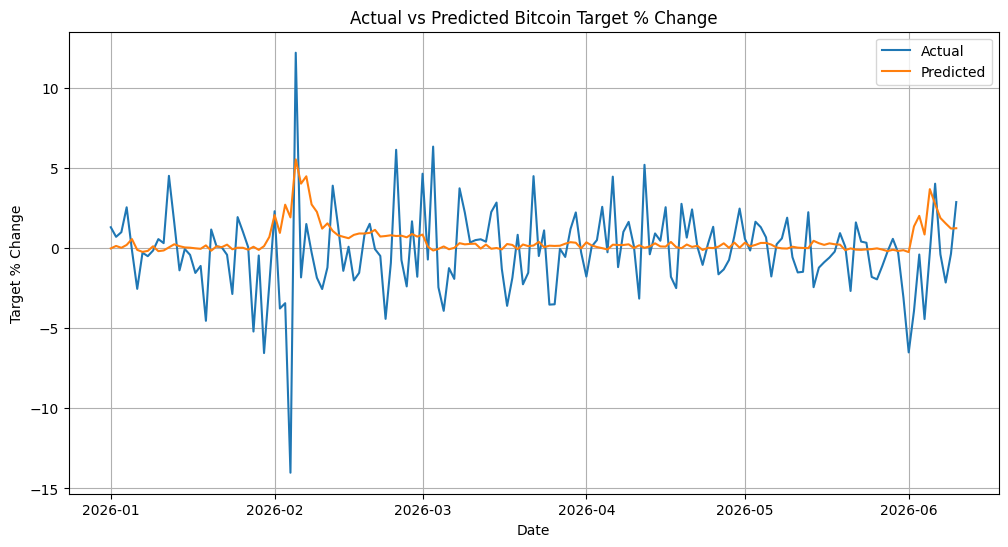

In [476]:
plt.figure(figsize=(12, 6))

plt.plot(comparison.index, comparison["actual"], label="Actual")
plt.plot(comparison.index, comparison["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

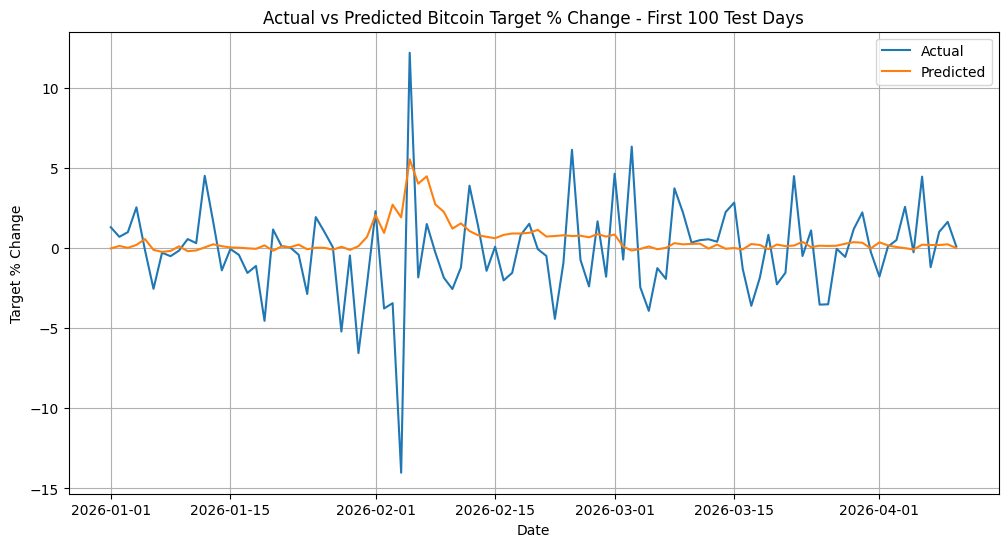

In [477]:
sample = comparison.head(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - First 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

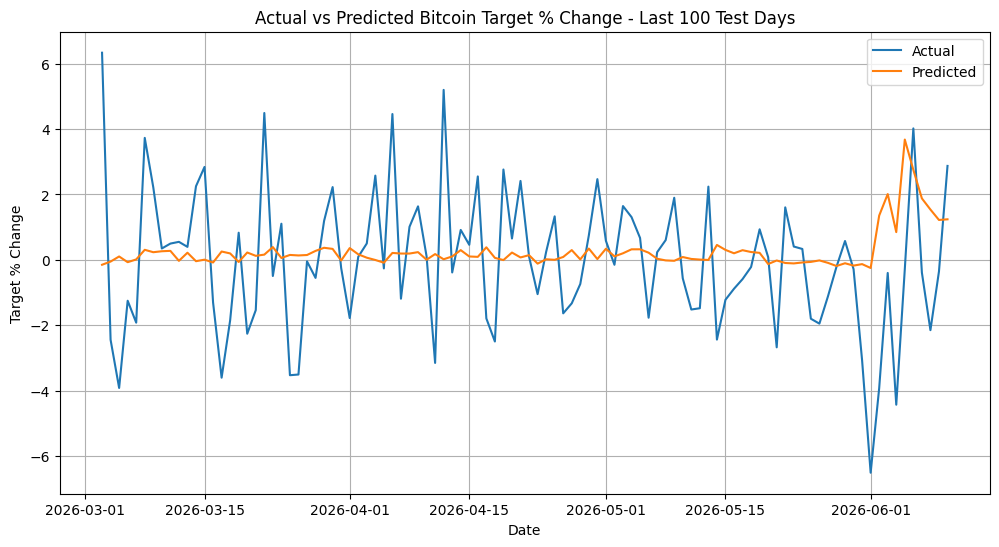

In [478]:
sample = comparison.tail(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - Last 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

KPI

In [479]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(comparison["actual"], comparison["predicted"])
rmse = np.sqrt(mean_squared_error(comparison["actual"], comparison["predicted"]))
r2 = r2_score(comparison["actual"], comparison["predicted"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.9613743472019325
RMSE: 2.7721881627079403
R2: -0.0957732119235093
